In [ ]:
# Create a helper class to load data with labels
from torch.utils.data import Dataset, DataLoader

class CPGDatasetWithLabels(Dataset):
    \"\"\"Dataset that combines graph tensors with labels from JSON split\"\"\"
    
    def __init__(self, graphs, indices, labels_dict):
        \"\"\"
        Args:
            graphs: List of graph objects/tensors from processed.pt
            indices: List of indices to use
            labels_dict: Dictionary mapping index to label
        \"\"\"
        self.graphs = graphs
        self.indices = indices
        self.labels_dict = labels_dict
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        graph_idx = self.indices[idx]
        graph = self.graphs[graph_idx]
        label = self.labels_dict.get(graph_idx, -1)
        return graph, label, graph_idx
    
    @property
    def label_distribution(self):
        \"\"\"Get distribution of labels in this split\"\"\"
        labels = [self.labels_dict.get(idx, -1) for idx in self.indices]
        unique, counts = np.unique(labels, return_counts=True)
        return dict(zip(unique, counts))

import numpy as np

# Create train and test datasets (assuming labels were loaded)
if 'labels' in locals():
    train_dataset = CPGDatasetWithLabels(processed_pt, train_indices, labels)
    test_dataset = CPGDatasetWithLabels(processed_pt, test_indices, labels)
    
    print("\n" + "="*50)
    print("DATASET OBJECTS CREATED")
    print("="*50)
    print(f"Train Dataset Size: {len(train_dataset)}")
    print(f"Test Dataset Size: {len(test_dataset)}")
    print(f"Train Label Distribution: {train_dataset.label_distribution}")
    print(f"Test Label Distribution: {test_dataset.label_distribution}")
    
    # Test loading a single sample
    print("\n--- Testing single sample loading ---")
    sample_graph, sample_label, sample_idx = train_dataset[0]
    print(f"Sample index: {sample_idx}")
    print(f"Sample label: {sample_label} ({id_map.get(str(sample_label), 'unknown')})")
    print(f"Sample graph type: {type(sample_graph)}")
else:
    print("Warning: Labels not loaded, cannot create datasets yet")

In [ ]:
# Analyze label distribution
print("\n" + "="*50)
print("LABEL DISTRIBUTION ANALYSIS")
print("="*50)

train_indices = split_data['train_indices']
test_indices = split_data['test_indices']
label_map = split_data['label_map']  # {'ai': 0, 'human': 1}
id_map = split_data['id_map']  # {'0': 'ai', '1': 'human'}

# Reconstruct labels if available - need to check the JSONL data
jsonl_file = Path("dataset/cpg/cpg_dataset_raw10.jsonl")

if jsonl_file.exists():
    # Load the original JSONL to get labels
    labels = {}
    with open(jsonl_file, 'r') as f:
        for idx, line in enumerate(f):
            record = json.loads(line)
            labels[idx] = label_map.get(record['target'], -1)  # Get label index
    
    # Count labels in train/test
    train_labels = [labels.get(idx, -1) for idx in train_indices]
    test_labels = [labels.get(idx, -1) for idx in test_indices]
    
    train_label_counts = {}
    test_label_counts = {}
    
    for label_name, label_idx in label_map.items():
        train_label_counts[label_name] = sum(1 for l in train_labels if l == label_idx)
        test_label_counts[label_name] = sum(1 for l in test_labels if l == label_idx)
    
    print(f"\nTrain Set Distribution:")
    for label_name, count in train_label_counts.items():
        pct = (count / len(train_indices)) * 100
        print(f"  {label_name}: {count} ({pct:.1f}%)")
    
    print(f"\nTest Set Distribution:")
    for label_name, count in test_label_counts.items():
        pct = (count / len(test_indices)) * 100
        print(f"  {label_name}: {count} ({pct:.1f}%)")
    
    print(f"\nTotal labels loaded: {len(labels)}")
else:
    print(f"JSONL file not found at {jsonl_file}")

In [ ]:
# Examine the structure of individual samples
print("\n" + "="*50)
print("SAMPLE DATA STRUCTURE")
print("="*50)

# If processed_pt is a list of graphs/samples
if isinstance(processed_pt, list) and len(processed_pt) > 0:
    sample = processed_pt[0]
    print(f"\nFirst sample type: {type(sample)}")
    
    # If it's a Data object from PyTorch Geometric
    if hasattr(sample, 'keys'):
        print(f"Sample attributes: {list(sample.keys())}")
        for key in sample.keys():
            attr = sample[key]
            if isinstance(attr, torch.Tensor):
                print(f"  {key}: Tensor {attr.shape}, dtype={attr.dtype}")
            else:
                print(f"  {key}: {type(attr)}")
    else:
        print(f"Sample attributes:")
        for attr in dir(sample):
            if not attr.startswith('_'):
                val = getattr(sample, attr, None)
                if isinstance(val, torch.Tensor):
                    print(f"  {attr}: Tensor {val.shape}, dtype={val.dtype}")
                elif isinstance(val, (int, str, float)):
                    print(f"  {attr}: {type(val).__name__}")

# Create mapping between dataset indices and graph indices
print(f"\n--- DATASET SIZE CHECK ---")
dataset_size = len(processed_pt) if isinstance(processed_pt, list) else processed_pt.shape[0] if hasattr(processed_pt, 'shape') else "Unknown"
print(f"Total graphs in processed.pt: {dataset_size}")
print(f"Train indices range: {min(split_data['train_indices'])} to {max(split_data['train_indices'])}")
print(f"Test indices range: {min(split_data['test_indices'])} to {max(split_data['test_indices'])}")
print(f"All indices are valid: {max(split_data['train_indices'] + split_data['test_indices']) < dataset_size if isinstance(dataset_size, int) else 'Check manually'}")

In [ ]:
# Load the processed tensor files from processed_homo
tensor_dir = Path("dataset/cpg/processed_homo")

# Load the main processed data
processed_pt = torch.load(tensor_dir / "processed.pt")
pre_filter_pt = torch.load(tensor_dir / "pre_filter.pt")
pre_transform_pt = torch.load(tensor_dir / "pre_transform.pt")

print("\n" + "="*50)
print("TENSOR FILES INFORMATION")
print("="*50)

print("\n--- processed.pt (main dataset) ---")
if isinstance(processed_pt, dict):
    print(f"Type: Dictionary with keys: {list(processed_pt.keys())}")
    for key, value in processed_pt.items():
        if isinstance(value, (torch.Tensor, list)):
            if isinstance(value, torch.Tensor):
                print(f"  {key}: Tensor with shape {value.shape}, dtype {value.dtype}")
            else:
                print(f"  {key}: List with {len(value)} items")
                if len(value) > 0 and isinstance(value[0], torch.Tensor):
                    print(f"    First item shape: {value[0].shape}")
        else:
            print(f"  {key}: {type(value)}")
elif isinstance(processed_pt, list):
    print(f"Type: List with {len(processed_pt)} items")
    if len(processed_pt) > 0:
        print(f"  First item type: {type(processed_pt[0])}")
        if hasattr(processed_pt[0], 'keys'):
            print(f"  First item keys: {list(processed_pt[0].keys())}")
else:
    print(f"Type: {type(processed_pt)}")
    print(f"Shape: {processed_pt.shape if hasattr(processed_pt, 'shape') else 'N/A'}")

print("\n--- pre_filter.pt ---")
if isinstance(pre_filter_pt, dict):
    print(f"Type: Dictionary with keys: {list(pre_filter_pt.keys())}")
else:
    print(f"Type: {type(pre_filter_pt)}")

print("\n--- pre_transform.pt ---")
if isinstance(pre_transform_pt, dict):
    print(f"Type: Dictionary with keys: {list(pre_transform_pt.keys())}")
else:
    print(f"Type: {type(pre_transform_pt)}")

In [ ]:
import torch
import json
from pathlib import Path

# Load the 2way_base_split_target.json
split_file = Path("dataset/data_split/2way_base_split_target.json")
with open(split_file, 'r') as f:
    split_data = json.load(f)

print("="*50)
print("SPLIT DATA STRUCTURE")
print("="*50)
print(f"Label Map: {split_data['label_map']}")
print(f"ID Map: {split_data['id_map']}")
print(f"Number of train indices: {len(split_data['train_indices'])}")
print(f"Number of test indices: {len(split_data['test_indices'])}")
print(f"\nFirst 10 train indices: {split_data['train_indices'][:10]}")
print(f"First 10 test indices: {split_data['test_indices'][:10]}")
print(f"\nTotal samples: {len(split_data['train_indices']) + len(split_data['test_indices'])}")

# Explore CPG Dataset

This notebook explores the `cpg_dataset_raw10.jsonl` file and the JSON split files.

In [ ]:
import json
import pandas as pd
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
from io import BytesIO
import seaborn as sns
import os

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
REPO_URL = "https://github.com/mohameddhameem/City-of-Agents.git"
REPO_NAME = "City-of-Agents"
BRANCH = "feat/updated-folder-structure"

if not os.path.exists(REPO_NAME):
    !git clone --branch {BRANCH} {REPO_URL}

os.chdir(REPO_NAME)

Cloning into 'City-of-Agents'...
remote: Enumerating objects: 559, done.
remote: Counting objects: 100% (559/559), done.
remote: Compressing objects: 100% (518/518), done.
remote: Total 559 (delta 59), reused 512 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (559/559), 11.83 MiB | 21.18 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [3]:
import sys
import subprocess
import os

!pip install -q torch torchvision torchaudio #--index-url https://download.pytorch.org/whl/cpu

# Install the local package in editable mode.
# Using '!' prefix ensures output is visible in the cell.
# Removed '-q' to show potential installation errors if any.
!pip install -q -e .

# Debugging paths
current_dir = os.getcwd()
# Add the 'src' directory to sys.path, as the package is likely within 'src/city_of_agents'
sys.path.insert(0, os.path.join(current_dir, 'src'))
sys.path.insert(0, current_dir) # Also keep the repo root in path for general imports if needed

print(f"Current working directory: {current_dir}")
print(f"sys.path entries (first 3): {sys.path[:3]}...") # Print first few entries
print(f"Does 'city_of_agents' directory exist in current_dir? {os.path.isdir(os.path.join(current_dir, 'city_of_agents'))}")
print(f"Does 'src' directory exist in current_dir? {os.path.isdir(os.path.join(current_dir, 'src'))}")
print(f"Does 'city_of_agents' directory exist in current_dir/src? {os.path.isdir(os.path.join(current_dir, 'src', 'city_of_agents'))}")

# Attempt to import
import city_of_agents
from city_of_agents import ast2pyg, joern
# Removed the import of 'city' as it causes a FileNotFoundError for 'simulation_data.csv' which is unrelated to the CPG dataset exploration.
# from city_of_agents.builders import city
from city_of_agents.utils import CPGHomoDataset, CPGHeteroDataset

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 85.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 106.3 MB/s eta 0:00:00
  Building editable for city-of-agents (pyproject.toml) ... done
Current working directory: /content/City-of-Agents
sys.path entries (first 3): ['/content/City-of-Agents', '/content/City-of-Agents/src', '/content']...
Does 'city_o

In [4]:
shared_folder_path = '/content/drive/MyDrive/CPG'
# list of all the files in the shared folder
files = os.listdir(shared_folder_path)
# iterate through the subfolders and print the files in each subfolder
for file in files:
    file_path = os.path.join(shared_folder_path, file)
    if os.path.isdir(file_path):
        print(f"Contents of subfolder '{file}':")
        subfolder_files = os.listdir(file_path)
        for subfile in subfolder_files:
            print(f"  {subfile}")
    else:
        print(file)

Contents of subfolder 'data_split':
  2way_base_split_target.json
  7way_base_split_model.json
  2way_50tasks_target.json
  7way_50tasks_model.json
Contents of subfolder 'raw10':
  cpg_dataset.jsonl
Contents of subfolder 'processed_hetero':
  processed.pt
  pre_transform.pt
  pre_filter.pt
Contents of subfolder 'processed_homo':
  processed.pt
  pre_filter.pt
  pre_transform.pt
Contents of subfolder 'raw':
  cpg_dataset.zip


In [8]:
file_path = Path("dataset/cpg/cpg_dataset_raw10.jsonl")

data = []
try:
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
except FileNotFoundError:
    print(f"File not found at {file_path.resolve()}")

if data:
    df = pd.DataFrame(data)
    print(f"Loaded {len(df)} records from CPG dataset")
    display(df.head())

Loaded 10 records from CPG dataset


,idx,target,model,code,graphml
0,8,human,human,"def delete_chat_sticker_set(self, chat_id):\n ...","<graphml \nxsi:schemaLocation=""http://graphml...."
1,5,human,human,"def _compute_layout_validator(self):\n """"""C...","<graphml \nxsi:schemaLocation=""http://graphml...."
2,1,human,human,"def reload(self):\n """"""Reload catalog i...","<graphml \nxsi:schemaLocation=""http://graphml...."
3,4,human,human,"def _RequestBodyFromData(data):\n """"""Gets r...","<graphml \nxsi:schemaLocation=""http://graphml...."
4,2,human,human,"def fetchUserInfo(self, *user_ids):\n ""...","<graphml \nxsi:schemaLocation=""http://graphml...."


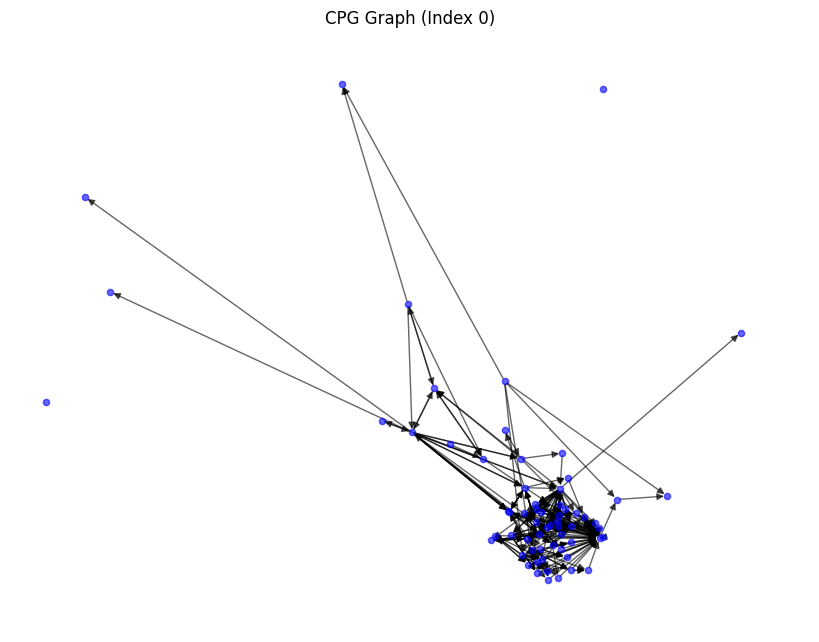

In [9]:
if data:
    sample_idx = 0
    sample = df.iloc[sample_idx]
    try:
        G = nx.read_graphml(BytesIO(sample['graphml'].encode('utf-8')))
        plt.figure(figsize=(8, 6))
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, node_size=20, alpha=0.6, node_color='blue')
        plt.title(f"CPG Graph (Index {sample_idx})")
        plt.show()
    except Exception as e:
        print(f"Graph error: {e}")

# Visualize Data Splits

We have two types of JSON files:
1. **Task Lists** (e.g., `2way_50tasks_target.json`): Contains few-shot tasks (1-shot, 2-shot, etc.).
2. **Base Splits** (e.g., `2way_base_split_target.json`): Contains train/test indices and label mappings.


==================== Analysing 2way_50tasks_target.json ====================
Type: Few-Shot Task List (50 tasks)


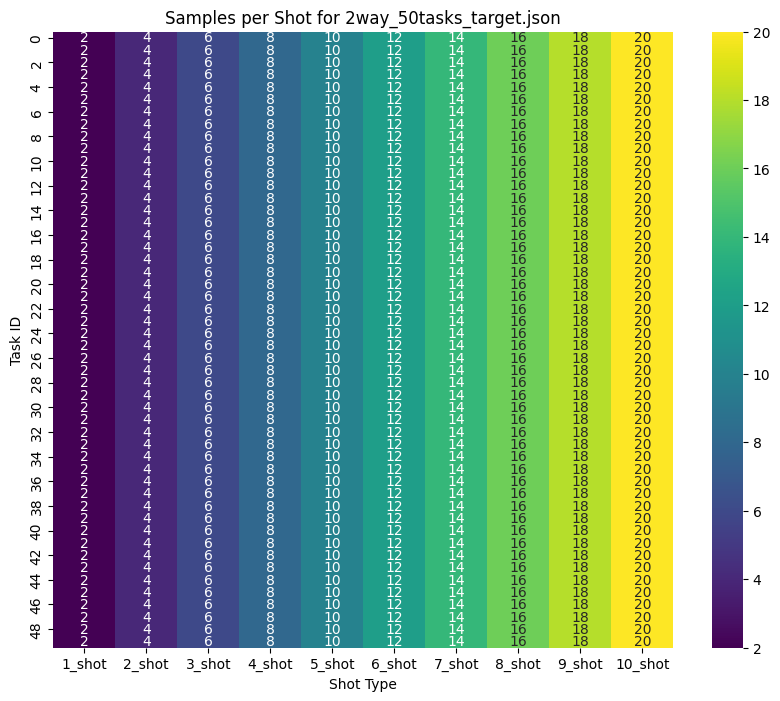


==================== Analysing 7way_50tasks_model.json ====================
Type: Few-Shot Task List (50 tasks)


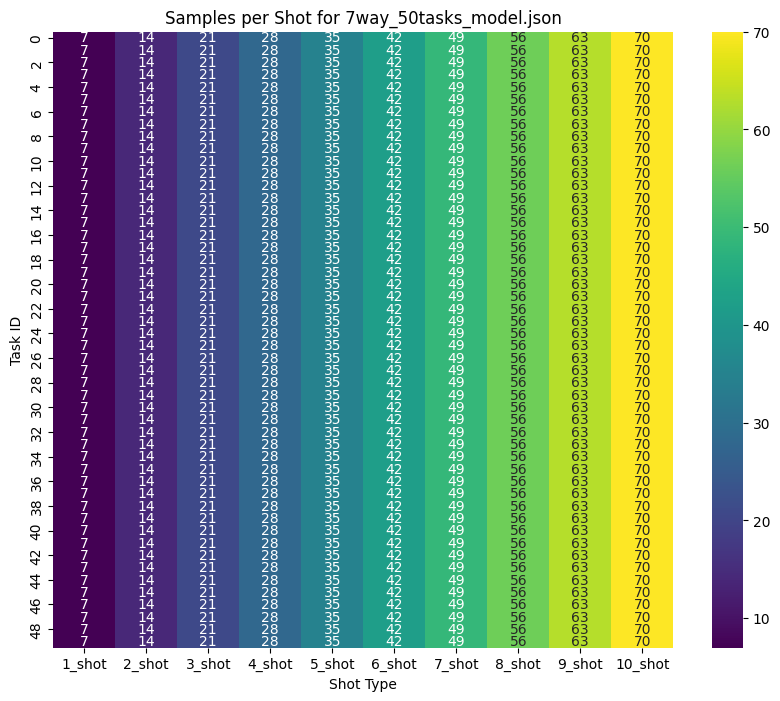


==================== Analysing 2way_base_split_target.json ====================
Type: Base Split (Train/Test Indices)
Label Map: {'ai': 0, 'human': 1}


/tmp/ipython-input-839550335.py:51: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




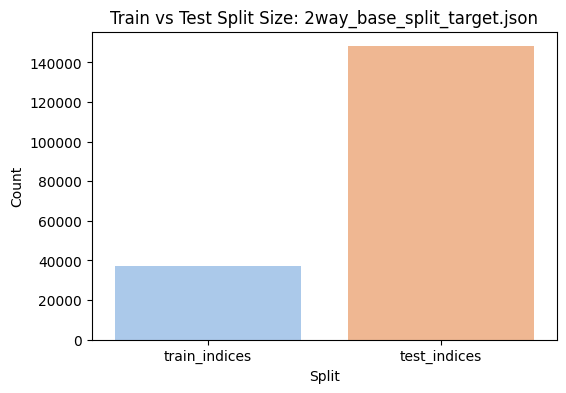

Indices Overlap: 0 (Success if 0)

==================== Analysing 7way_base_split_model.json ====================
Type: Base Split (Train/Test Indices)
Label Map: {'codellama': 0, 'gpt': 1, 'human': 2, 'llama3.1': 3, 'nan': 4, 'nxcode': 5, 'qwen1.5': 6}


/tmp/ipython-input-839550335.py:51: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




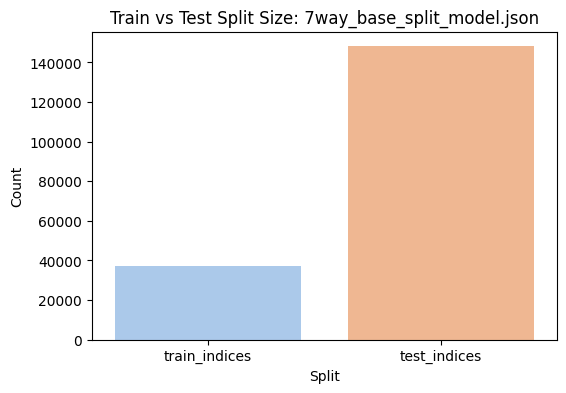

Indices Overlap: 0 (Success if 0)


In [10]:
split_dir = Path("dataset/data_split")
json_files = list(split_dir.glob("*.json"))

def visualize_split_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = json.load(f)
    
    print(f"\n{'='*20} Analysing {file_path.name} {'='*20}")

    if isinstance(content, list):
        print(f"Type: Few-Shot Task List ({len(content)} tasks)")
        
        shots_data = []
        for task in content:
            task_id = task.get('task_id', 'unknown')
            data_dict = task.get('data', {})
            for shot_key, classes_dict in data_dict.items():
                total_samples = sum(len(indices) for indices in classes_dict.values())
                shots_data.append({'Task ID': task_id, 'Shot Type': shot_key, 'Samples': total_samples})
        
        if shots_data:
            shots_df = pd.DataFrame(shots_data)
            heatmap_data = shots_df.pivot(index='Task ID', columns='Shot Type', values='Samples')
            shot_cols = sorted(heatmap_data.columns, key=lambda x: int(x.split('_')[0]) if '_' in x else x)
            heatmap_data = heatmap_data[shot_cols]

            plt.figure(figsize=(10, 8))
            sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="viridis")
            plt.title(f"Samples per Shot for {file_path.name}")
            plt.ylabel("Task ID")
            plt.xlabel("Shot Type")
            plt.show()
        else:
             print("No valid shot data found to visualize.")

    elif isinstance(content, dict):
        print("Type: Base Split (Train/Test Indices)")
        
        if 'label_map' in content:
            print("Label Map:", content['label_map'])
            
        keys = ['train_indices', 'test_indices']
        metrics = []
        for k in keys:
            if k in content:
                metrics.append({'Split': k, 'Count': len(content[k])})
        
        if metrics:
            metrics_df = pd.DataFrame(metrics)
            plt.figure(figsize=(6, 4))
            sns.barplot(data=metrics_df, x='Split', y='Count', palette="pastel")
            plt.title(f"Train vs Test Split Size: {file_path.name}")
            plt.show()

            if 'train_indices' in content and 'test_indices' in content:
                train_set = set(content['train_indices'])
                test_set = set(content['test_indices'])
                overlap = train_set.intersection(test_set)
                print(f"Indices Overlap: {len(overlap)} (Success if 0)")

for jf in json_files:
    visualize_split_file(jf)